# **EDA**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### **links.csv** *(used for presentation only)*

In [17]:
links = pd.read_csv("Data/links.csv")

display(links.head())
print()

display(links.info())
print("Why is the type of 'tmdbId' float? Convert to int to use correctly with URL:s?")
print()

print(f"{sum(links["tmdbId"].isna())} missing values in 'tmdbId'\n")

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0



<class 'pandas.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  86537 non-null  int64  
 1   imdbId   86537 non-null  int64  
 2   tmdbId   86411 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.0 MB


None

Why is the type of 'tmdbId' float? Convert to int to use correctly with URL:s?

126 missing values in 'tmdbId'



In [32]:
movies = pd.read_csv("Data/movies.csv")

display(movies.head())
print("NOTE TO SELF:\n"
      "* Sep=| in genres\n"
      "* movieId is used as identifier (see links.csv above)")

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


NOTE TO SELF:
* Sep=| in genres
* movieId is used as identifier (see links.csv above)


In [33]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  86537 non-null  int64
 1   title    86537 non-null  str  
 2   genres   86537 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.0 MB


In [ ]:
print(movies["genres"].value_counts())
print(f"\n{movies["genres"].value_counts().sum()} unique combinations of genres, but only 19 unique genres (according to the README).\n")

unique_genres = movies["genres"].str.split("|").explode().unique()
IMAX = movies["genres"] == "IMAX"
print(movies[IMAX])

print()
print(f"There are {len(unique_genres)} unique genres, see below:")
display(unique_genres)

print("NOTE TO SELF:\n"
      "* '(no genres listed)' is used instead of NaN. Convert these to NaN and perhaps impute? 7 060 missing values!\n"
      "* Movies with multiple genres makes value_counts() misguiding.\n"
      "* The 19th 'genre' is 'IMAX', which is a display format and not a genre.\nThis is okay if combined with other genres, but the movie 'Encounter in the\nThird Dimension (1999)' has it as its only genre and it's actually a 'Documentary'.\nShould I impute this? Would probably matter little, but it's an easy task.")

genres
Drama                                                    12246
Documentary                                               8064
Comedy                                                    7689
(no genres listed)                                        7060
Comedy|Drama                                              3196
                                                         ...  
Action|Adventure|Drama|Fantasy|Mystery|Romance|Sci-Fi        1
Adventure|Animation|Comedy|Western                           1
Animation|Children|Comedy|Fantasy|Romance                    1
Comedy|Horror|Mystery|Sci-Fi|Thriller                        1
Action|Adventure|Drama|Horror|Mystery|Thriller               1
Name: count, Length: 1796, dtype: int64

86537 unique combinations of genres, but only 19 unique genres (according to the README).

      movieId                                    title genres
4356     4460  Encounter in the Third Dimension (1999)   IMAX

There are 20 unique genres, see below:


<StringArray>
[         'Adventure',          'Animation',           'Children',
             'Comedy',            'Fantasy',            'Romance',
              'Drama',             'Action',              'Crime',
           'Thriller',             'Horror',            'Mystery',
             'Sci-Fi',               'IMAX',        'Documentary',
                'War',            'Musical',            'Western',
          'Film-Noir', '(no genres listed)']
Length: 20, dtype: str

NOTE TO SELF:
* '(no genres listed)' is used instead of NaN. Convert these to NaN? 7 060 missing values!
* Movies with multiple genres makes value_counts() misguiding.
* The 19th 'genre' is 'IMAX', which is a display format and not a genre.
This is okay if combined with other genres, but the movie 'Encounter in the
Third Dimension (1999)' has it as its only genre and it's actually a 'Documentary'.
Should I impute this? Would probably matter little, but it's an easy task.


In [111]:
mask_no_genre = movies["genres"] == "(no genres listed)"
display(movies[mask_no_genre])

print("NOTE TO SELF:\n"
      "* Impute from movielens.org, imdb.com or themoviedb.org with the help of the movieId column?\n")

,movieId,title,genres
15884,83773,Away with Words (San tiao ren) (1999),(no genres listed)
16063,84768,Glitterbug (1994),(no genres listed)
16354,86493,"Age of the Earth, The (A Idade da Terra) (1980)",(no genres listed)
16494,87061,Trails (Veredas) (1978),(no genres listed)
17410,91246,Milky Way (Tejút) (2007),(no genres listed)
...,...,...,...
86460,288739,Commercial Entertainment Product (1992),(no genres listed)
86464,288749,In Good Conscience: Sister Jeannine Gramick's ...,(no genres listed)
86490,288843,Mongoloid (1978),(no genres listed)
86493,288849,Colaholic (2018),(no genres listed)


NOTE TO SELF:
* Impute from movielens.org, imdb.com or themoviedb.org with the help of the movieId column?



In [ ]:
mask_identical_names = movies["title"].map(movies["title"].value_counts() > 1)
print(movies["title"][mask_identical_names].value_counts())

print("\nNOTE TO SELF:\n"
      "* movies.csv contains some duplicates (i.e. 'Lagaan: Once Upon a Time in India (2001)').\n"
      "* Some movies with identical name+year are simply different movies (i.e. 'Dracula (1931)'.\n"
      "* Is it possible to handle duplicates in some way? How do I separate them from non-duplicate movies that just share the same identical name?\n")

title
Alone (2020)                                 4
Journey to the Center of the Earth (2008)    3
The Plague (2006)                            3
The Box (2021)                               3
Aladdin (1992)                               2
                                            ..
Hawa (2022)                                  2
Medusa (2022)                                2
The Harbinger (2022)                         2
The Other Side (2020)                        2
Carmen (2022)                                2
Name: count, Length: 202, dtype: int64

NOTE TO SELF:
* movies.csv contains some duplicates (i.e. 'Lagaan: Once Upon a Time in India (2001)').
* Some movies with identical name+year as another are simply different movies (i.e. 'Dracula (1931)'.
* Is it possible to handle duplicates in some way? How do I separate them from non-duplicate movies that just share the same identical name?



In [ ]:
ratings = pd.read_csv("Data/ratings.csv")
display(ratings.head())

print("NOTE TO SELF:\n" \
"* timestamp column is irrelevant (seconds since midnight (UTC) of January 1, 1970 according to README).")

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


NOTE TO SELF:
* timestamp column is irrelevant (seconds since midnight (UTC) of January 1, 1970 according to README).


In [ ]:
ratings.info()

print("NOTE TO SELF:\n" \
"* Many entries (over 33 million). Sample percent of total users or maybe percent of ratings per user? 10%, 20%, 30%?")

<class 'pandas.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 1.0 GB


In [117]:
ratings["rating"].describe().round(1)

count    33832162.0
mean            3.5
std             1.1
min             0.5
25%             3.0
50%             4.0
75%             4.0
max             5.0
Name: rating, dtype: float64

NOTE TO SELF:
* Scewed.
* Few low ratings, mostly 3-4.


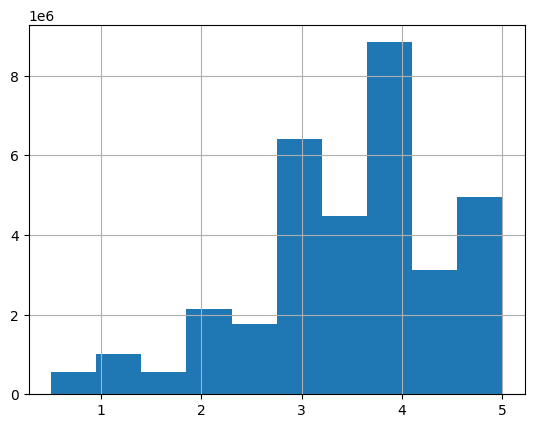

In [ ]:
ratings["rating"].hist()

print("NOTE TO SELF:\n" \
"* Scewed.\n" \
"* Few low ratings, mostly 3-4.")

In [132]:
tags = pd.read_csv("Data/tags.csv")
display(tags.head())

print("NOTE TO SELF:\n" \
"* Use tags with NLP. Combine with genres first?")

,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


NOTE TO SELF:
* Use tags with NLP. Combine with genres first?
